<a href="https://colab.research.google.com/github/dymiyata/python-pro-intro-to-ml-spring-2026/blob/main/polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial Regression

Import the usual stuff.

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Here I am creating some simulated data

In [ ]:
X_train = np.linspace(-3, 3, 20)
Y_train = 3 * X_train + 5 * X_train ** 2 + 7 + 6 * np.random.randn(20)

Let's visualize a scatter plot of this data.

<Axes: >

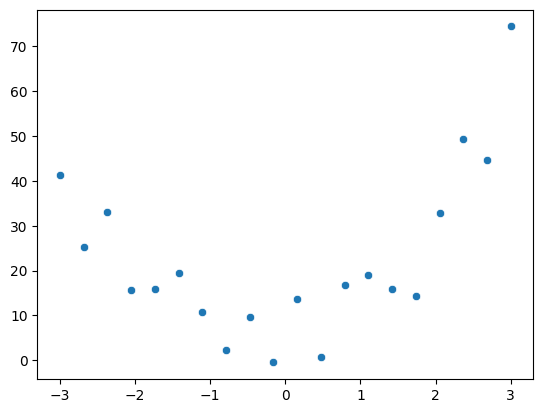

In [ ]:
sns.scatterplot(x=X_train, y=Y_train)

Now let's create a linear regression model for this data.  

In [ ]:
model = LinearRegression()

Because of how the data was created, we need to add $x^2$ as a feature to our feature matrix.  To do this we can use `np.column_stack()` and pass as a argument, a list of all the arrays we want to be the columns of our matrix.  

Let's save the feature matrix in a variable called `poly_features`

In [ ]:
poly_features = np.column_stack([X_train, X_train ** 2]) # define second feature, to be the first one squared
print(poly_features[0:5])
print(X_train[0:5])

[[-3.          9.        ]
 [-2.68421053  7.20498615]
 [-2.36842105  5.60941828]
 [-2.05263158  4.2132964 ]
 [-1.73684211  3.0166205 ]]
[-3.         -2.68421053 -2.36842105 -2.05263158 -1.73684211]


Now we train the model using `poly_features` as the feature matrix.

In [ ]:
model.fit(poly_features, Y_train)

LinearRegression()

To visualize our model, we can save the predicted values in an array. Then plot the prediction over the actual data.

In [ ]:
Y_pred = model.predict(poly_features)

<Axes: >

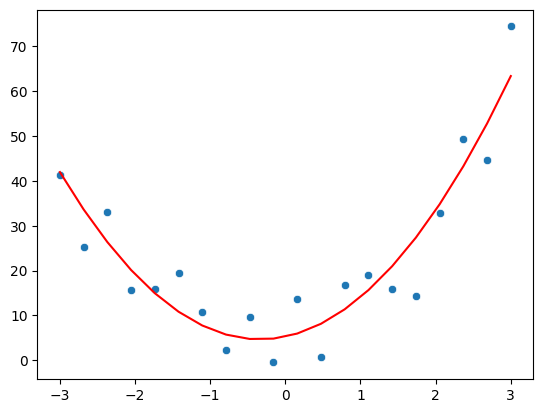

In [ ]:
sns.scatterplot(x=X_train, y=Y_train)
sns.lineplot(x=X_train, y=Y_pred, color="red")

## Overfitting

Sometimes if you add too many features, this can lead to overfitting.  

Let's see what would happen if instead of just $x$ and $x^2$ as features, we also used:
$$ x^3, x^4, x^5, \dots, x^{20} $$

so our model is a degree 20 polynomial.

In [ ]:
### Aside on list comprehension
# Suppose we want the list [0, 2, 4, 6, ... , 48, 50]

my_list = []
for i in range(0, 51, 2):
  my_list.append(i)
print(my_list)

my_list2 = [i for i in range(0, 51, 2)] # This syntax is called list comprehension
print(my_list2)


my_list = []
for i in range(51):
  if i % 2 == 0:
    my_list.append(i)
print(my_list)

my_list2 = [i for i in range(51) if i % 2 == 0] # List comprehension with an if statement
print(my_list2)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]


In [ ]:
# feature_list = []
# for i in range(1, 21):
#   feature_list.append(X_train ** i)
# feature20 = np.column_stack(feature_list)

feature20 = np.column_stack([X_train ** i for i in range(1, 21)])

In [ ]:
model.fit(feature20, Y_train)

LinearRegression()

In [ ]:
Y_pred20 = model.predict(feature20)

<Axes: >

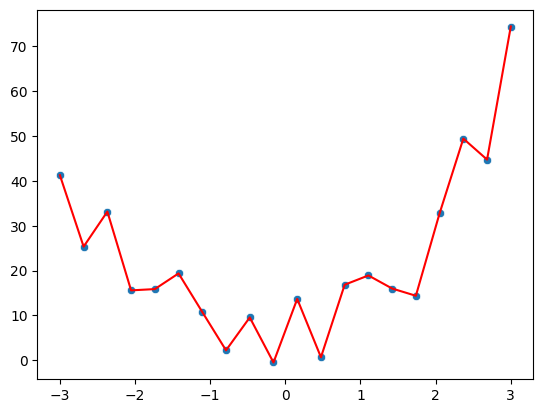

In [ ]:
sns.scatterplot(x=X_train, y=Y_train)
sns.lineplot(x=X_train, y=Y_pred20, color="red")

In [ ]:
print(mean_squared_error(Y_pred, Y_train))
print(mean_squared_error(Y_pred20, Y_train))

42.98629098661418
3.5985637706614864e-06
